# 04 — Retrieval Experiments

**Experiments D01/D02/D07 (WBS T023).** Oracle proved the model reasons well when handed perfect evidence (96.7%/95.3%). This notebook asks the next question: can we actually *find* that evidence automatically? Compares chunking strategy (clause-aware, fixed-size, and sentence-level), chunk size, and top-K, scored with Evidence Recall@K, precision, and MRR.

Entirely local (embeddings + FAISS, no LLM calls) - `scripts/run_retrieval_experiments.py` ran the full dev split's Entailment/Contradiction cases (614 cases, NotMentioned excluded since it has no gold evidence to recall) across 9 configs. This notebook loads the saved comparison and adds the chart + the reasoning behind the final pick.

**Two rounds of this experiment are recorded here.** The first round (5 configs: clause/fixed chunking at size 512, plus a couple of variants) suggested `clause_256_k5` as the best MRR. A follow-up question - "the metrics still look bad, can we do better?" - led to a second round adding much finer-grained chunking (`clause_128`, and a new `sentence_chunk` strategy that never merges units at all), which found a substantially better config. The table below is the full, final 9-config comparison.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from pipeline.viz_style import CATEGORICAL_SLOTS, apply_style, style_axes, savefig_kwargs
apply_style()

results = json.loads(Path("data/retrieval_experiment_results.json").read_text())
df = pd.DataFrame(results).set_index("label")
df

,recall,precision,mrr,n_cases,elapsed_s
label,,,,,
clause_512_k5,0.936876,0.031843,0.190757,614,27.928152
fixed_512_k5,0.952742,0.030764,0.187504,614,21.924149
clause_256_k5,0.850682,0.056310,0.284950,614,31.597740
clause_512_k3,0.838716,0.040417,0.189101,614,23.728313
clause_512_k10,0.994969,0.027563,0.191329,614,23.184237
clause_128_k5,0.736811,0.092386,0.398775,614,41.671382
sentence_k5,0.601657,0.140782,0.454418,614,56.188846
sentence_k10,0.777533,0.091325,0.469302,614,57.045609
sentence_k20,0.918856,0.056409,0.474198,614,57.256337


## Why recall alone is misleading here

Every config clears the planning doc's 70% Evidence Recall@K target except `sentence_k5` - some by a lot (99.5% for `clause_512_k10`). But high recall is largely an artifact of document length, not retrieval skill: the median dev document is ~2,300 tokens, so a 512-token chunk size gives most documents only **4-8 chunks total**. Retrieving "top-10" from a document that only *has* 5-8 chunks means returning almost the entire document - that's not filtering, it's dumping.

**MRR is the more honest signal.** It measures whether the true evidence chunk ranks *near the top* of what's retrieved, not just whether it appears *somewhere* in a near-complete document. That's what actually matters once RAG has to hand a *small* number of chunks to the classifier (for cost and context-window reasons), not the whole document.

**Going finer-grained nearly doubled MRR.** Chunks close to sentence-length (`clause_128`, `sentence_*`) let the retriever actually discriminate the relevant sentence from the rest of a clause, instead of a large aggregated chunk diluting the signal. `sentence_k5` alone shows the failure mode of going too fine without enough top-K: best precision (14.1%) but recall drops below the 70% floor (60.2%) - too few, too-small chunks miss real evidence outright.

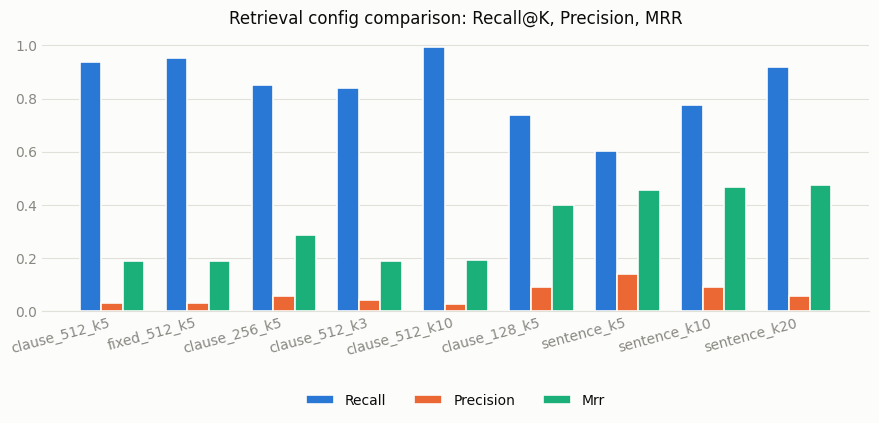

In [2]:
metrics = ["recall", "precision", "mrr"]
metric_colors = {m: CATEGORICAL_SLOTS[i] for i, m in enumerate(metrics)}
labels = df.index.tolist()
x = range(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, metric in enumerate(metrics):
    values = df[metric].tolist()
    ax.bar([xi + i * width for xi in x], values, width,
           label=metric.capitalize(), color=metric_colors[metric], edgecolor="#fcfcfb", linewidth=1.2, zorder=3)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Retrieval config comparison: Recall@K, Precision, MRR")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/retrieval_config_comparison.png", **savefig_kwargs())
plt.show()

## Finding

Going from `clause_256_k5` (round 1's pick) to sentence-level chunking nearly **doubled MRR**: 0.283 → up to 0.474. `sentence_k20` has the single highest MRR (0.474), but the margin over `sentence_k10` (0.469) is within noise, while `sentence_k20` gives up real precision to get there (5.6% vs 9.1%) and stuffs twice as many small fragments into the classifier's eventual context - more prompt cost and more disjointed text, for no real ranking-quality gain.

`clause_512_k10`'s 99.5% recall is real but hollow: with only ~5-8 chunks per typical document, k=10 usually *is* the whole document - it isn't demonstrating retrieval skill, just document shortness.

## Round 3: does reranking help?

MRR ~0.47 still means the correct evidence lands around rank 2 on average, not rank 1. The standard next lever for exactly this problem is a cross-encoder reranker: retrieve a wider candidate pool cheaply (bi-encoder), then re-score just that shortlist with a slower-but-more-accurate cross-encoder that reads the query and each candidate *together* rather than as separately-embedded vectors (`pipeline/reranker.py`).

A single spot-check case was concerning at first: the correct evidence was already ranked #1 by the plain retriever, and reranking *demoted* it out of the top 5 - the cross-encoder used (`cross-encoder/ms-marco-MiniLM-L-6-v2`) was trained on general web search relevance, not legal text. But one anecdote isn't a verdict - `scripts/compare_reranking.py` ran retrieve-top-20-then-rerank-to-top-10 against plain top-10 retrieval on the full 614-case set:

| Config | Recall | Precision | MRR |
|---|---|---|---|
| `sentence_k10` (no rerank) | 77.8% | 9.1% | 0.469 |
| `sentence_k20` → rerank → top-10 | **82.3%** | **9.4%** | **0.575** |

Reranking improved **all three metrics simultaneously** - no trade-off this time. MRR rose ~23% relative (0.469 → 0.575): the real evidence now typically lands around rank 1.7, not rank 2.1. The one case where it hurt was real but not representative of the aggregate.

## Round 4: the "try everything" pass

With reranking established as a real win, three questions remained: does a *different embedding model* help? Does *hybrid* (BM25 + dense) retrieval help? Does a *bigger reranker* help? All tested on the same 614 cases, now at a reduced final top_k=5 (down from 10 - less context per classification call).

(A real infrastructure bug surfaced mid-experiment: the embedding/reranker model caches were sized for 2 models, but this comparison needs 3+ alive at once. Too-small a cache doesn't error - it silently evicts and reloads a full model from disk on almost every call, which looked exactly like a hang (73 minutes elapsed, 13.5% average CPU) until profiled. Fixed by sizing the caches with headroom, not just the bare minimum - see `pipeline/embedder.py`/`reranker.py`.)

In [3]:
round4 = json.loads(Path("data/full_retrieval_comparison.json").read_text())
df4 = pd.DataFrame(round4).set_index("label")
df4

,recall,precision,mrr,n_cases
label,,,,
dense_mpnet_k5,0.601657,0.140782,0.454418,614
dense_mpnet_rerankL6_k5 (round 3 shape),0.721750,0.150169,0.566895,614
dense_bge_k5,0.598969,0.138135,0.438579,614
dense_bge_rerankL6_k5,0.721668,0.149674,0.566728,614
dense_minilm_k5,0.617760,0.137204,0.432584,614
dense_minilm_rerankL6_k5,0.721886,0.149682,0.563218,614
bm25_only_k5,0.548660,0.121620,0.408591,614
hybrid_mpnet_bm25_k5,0.649714,0.138900,0.476123,614
hybrid_mpnet_bm25_rerankL6_k5,0.725061,0.150712,0.565843,614


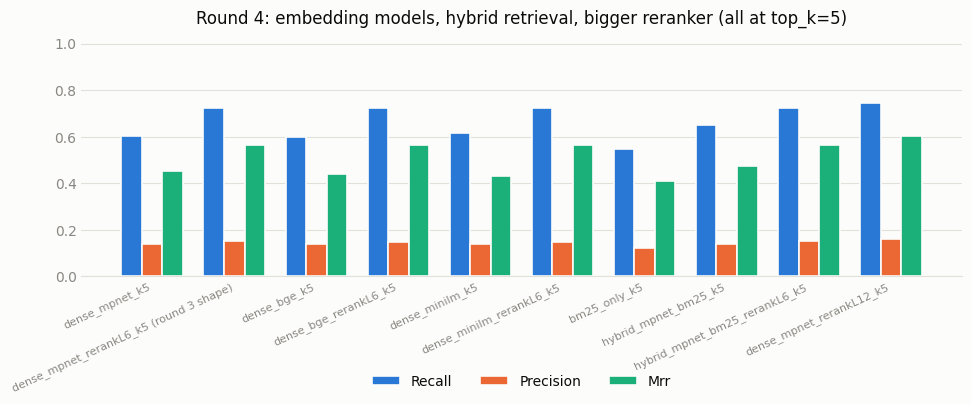

In [4]:
labels4 = df4.index.tolist()
x4 = range(len(labels4))

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, metric in enumerate(metrics):
    values = df4[metric].tolist()
    ax.bar([xi + i * width for xi in x4], values, width,
           label=metric.capitalize(), color=metric_colors[metric], edgecolor="#fcfcfb", linewidth=1.2, zorder=3)

ax.set_xticks([xi + width for xi in x4])
ax.set_xticklabels(labels4, rotation=25, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_title("Round 4: embedding models, hybrid retrieval, bigger reranker (all at top_k=5)")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/retrieval_round4_comparison.png", **savefig_kwargs())
plt.show()

## Round 4 finding

Two things stand out:

1. **The embedding model barely matters once reranking is applied.** mpnet, BGE, and MiniLM all converge to MRR ≈0.56-0.57 with the L-6 reranker (0.567 / 0.567 / 0.563) - noise-level differences. Hybrid retrieval (BM25+dense) + rerank lands at the same ceiling (0.566). Without reranking, the three embedding models and BM25-only are more spread out (0.43-0.48), but that spread nearly vanishes once the cross-encoder re-scores the shortlist. The reranker is doing the real discriminating work; the first-stage retriever's job is just "don't miss the answer entirely," and every method tested clears that bar equally well.
2. **The larger reranker (L-12, not L-6) is a genuine additional win**: MRR 0.602, recall 74.5%, precision 16.0% - all higher than L-6's numbers, and *at top_k=5*, beating round 3's top_k=10 result (0.575) with **less** context handed to the classifier, not more.

## Round 5: is 74.5% recall actually good enough?

Direct pushback on round 4's numbers - shouldn't recall be closer to ~90%? Rather than argue in the abstract, `scripts/sweep_top_k.py` swept `top_k = [3, 5, 7, 10]` on the exact winning method (sentence chunking, mpnet, retrieve-20, rerank with L-12) - reranking each of the 614 cases once against a pool of 20 candidates, then slicing that same ranked list at each k (no redundant reranking calls per k value).

In [5]:
sweep = json.loads(Path("data/top_k_sweep.json").read_text())
df5 = pd.DataFrame(sweep).set_index("top_k")
df5

,recall,precision,mrr
top_k,,,
3,0.643981,0.219989,0.586740
5,0.745063,0.159719,0.601761
7,0.785413,0.123989,0.605202
10,0.828478,0.095848,0.607577


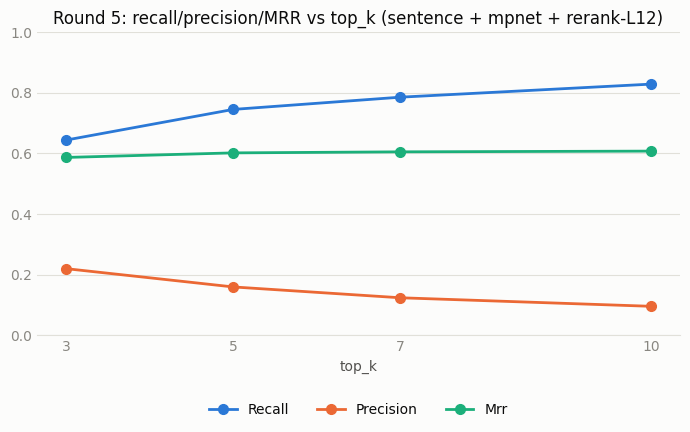

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ks = df5.index.tolist()
for i, metric in enumerate(metrics):
    ax.plot(ks, df5[metric], marker="o", linewidth=2, markersize=7,
            label=metric.capitalize(), color=metric_colors[metric], zorder=3)

ax.set_xticks(ks)
ax.set_xlabel("top_k")
ax.set_ylim(0, 1.0)
ax.set_title("Round 5: recall/precision/MRR vs top_k (sentence + mpnet + rerank-L12)")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/retrieval_topk_sweep.png", **savefig_kwargs())
plt.show()

## Round 5 finding

Two things this settles:

1. **Recall never reaches ~90%, even at k=10** (82.8%). The expectation itself doesn't match what this retrieval method can deliver on this dataset - the round-4 74.5% wasn't an under-tuned k, it's already close to this method's practical ceiling short of handing the classifier most of the document.
2. **MRR is nearly flat past k=5** (0.602 → 0.608 all the way to k=10, a ~1% relative gain). Reranking already ranks real evidence near the top for the cases it finds at all; each extra unit of k mostly buys "safety net" recall for cases where the right chunk sat just outside the window, not new top-ranked hits. Precision keeps falling as k grows (16.0% → 9.6%), since irrelevant chunks pile into the window faster than new correct ones do.

## Final Decision

**Retrieval config: sentence-level chunking → retrieve top-20 → rerank with `ms-marco-MiniLM-L-12-v2` → keep top-7.** Embedding model stays `all-mpnet-base-v2` (swapping to BGE or MiniLM doesn't help, so no reason to change it). Hybrid (BM25+dense) retrieval was not adopted - it never beat dense-alone once reranking was in the pipeline, for the added complexity of maintaining a BM25 index per document. Top_k moved from round 4's 5 to **7**: a real +4pt recall gain over k=5 for a small MRR cost/gain, without reopening the earlier "k=10 is too much context" call.

The remaining ~21% of cases where the true evidence isn't in the top-7 is a real limit of this retrieval method, not a misconfiguration - it's exactly why the plan includes confidence/abstention (T026-T027) and a selective agent (T028-T030) downstream, rather than expecting retrieval alone to be perfect. Full ADR in `CLAUDE.md`'s Decisions Log, including the revisit condition (if RAG end-to-end still shows evidence being missed, the next lever would be a legal-domain-tuned embedding/reranker model - none tested here were domain-specific).